# About Dataset

This synthetic dataset simulates real-world road conditions and associated accident risk probabilities. It has been generated to support machine learning tasks focused on predicting accident-prone road segments based on environmental, infrastructural, and temporal variables.

The dataset is entirely simulated using randomized distributions and domain-informed logic. It is shared under the CC0 Public Domain license, making it free for anyone to use, remix, or build upon
🎯 Use Case

The primary use case is training machine learning models to predict the likelihood of accidents on different types of roads using features such as:

    Road curvature and number of lanes
    Weather and lighting conditions
    Presence of road signs
    Holiday or school season flags
    Speed limits, time of day, and more

You can apply regression or classification techniques, test feature importance, and explore model interpretability techniques like SHAP or LIME.
💡 Inspiration

This dataset can be used for:

    Building and evaluating risk prediction models
    Feature engineering and selection
    Synthetic data testing and augmentation
    Public safety prototypes or urban planning simulations


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [33]:
df_train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [34]:
print(df_train.shape)
print(df_test.shape)

(517754, 14)
(172585, 13)


In [35]:
df_test.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
dtype: int64

In [36]:
df_train.drop(['id','num_lanes','time_of_day'],axis=1,inplace=True)
df_test.drop(['id','num_lanes','time_of_day'],axis=1,inplace=True)

In [37]:
df_train.isnull().sum()

road_type                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [38]:

df_test.isnull().sum()

road_type                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
holiday                   0
school_season             0
num_reported_accidents    0
dtype: int64

In [39]:
# take the first 1000 rows from each dataset
df_train_sample = df_train.head(1000).reset_index(drop=True).copy()
df_test_sample = df_test.head(1000).reset_index(drop=True).copy()

print("df_train_sample shape:", df_train_sample.shape)
print("df_test_sample shape: ", df_test_sample.shape)

# quick preview
df_train_sample.head(3)
df_test_sample.head(3)

df_train_sample shape: (1000, 11)
df_test_sample shape:  (1000, 10)


,road_type,curvature,speed_limit,lighting,weather,road_signs_present,public_road,holiday,school_season,num_reported_accidents
0,highway,0.34,45,night,clear,True,True,True,True,1
1,urban,0.04,45,dim,foggy,True,False,True,False,0
2,urban,0.59,35,dim,clear,True,False,True,True,1


In [40]:
# create copies so original dfs remain available
df_train_missing = df_train.copy()
df_train_sample_missing = df_train_sample.copy()

# reproducible random selection
rng = np.random.RandomState(42)

# specify fraction of missing values to inject per column
missing_config = {
    'curvature': 0.02,           # 2% missing (numeric)
    'lighting': 0.05,            # 5% missing (categorical)
    'weather': 0.03,             # 3% missing (categorical)
    'road_signs_present': 0.01,  # 1% missing (boolean -> will become object/float after NaN)
    'lighting': 0.01,           # 1% missing (integer)
    # 'accident_risk': 0.04        # 4% missing (numeric target/score)
    # 'curvature' : 0.02,           # 2% missing (numeric)
}

# helper to inject missing values into a dataframe
def inject_missing(df, config, rng):
    n_rows = len(df)
    for col, frac in config.items():
        n_missing = int(np.floor(frac * n_rows))
        if n_missing <= 0:
            continue
        idx = rng.choice(df.index, size=n_missing, replace=False)
        df.loc[idx, col] = np.nan
    return df

# inject into full training set and sample (use different RNG states for variety)
# df_train_missing = inject_missing(df_train_missing, missing_config, np.random.RandomState(42))
df_train_sample_missing = inject_missing(df_train_sample_missing, missing_config, np.random.RandomState(7))

# quick check of introduced missing values
# print("Missing counts in df_train_missing:")
# print(df_train_missing.isnull().sum())
print("\nMissing counts in df_train_sample_missing:")
print(df_train_sample_missing.isnull().sum())


Missing counts in df_train_sample_missing:
road_type                  0
curvature                 20
speed_limit                0
lighting                  10
weather                   30
road_signs_present        10
public_road                0
holiday                    0
school_season              0
num_reported_accidents     0
accident_risk              0
dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9984\2678224904.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[idx, col] = np.nan


In [41]:
# Save processed and original datasets to disk
# Uses existing dataframe variables from the notebook
df_train_sample_missing.to_csv('df_train_sample_missing.csv', index=False)


In [42]:
df_train_sample_missing.sample(5)

,road_type,curvature,speed_limit,lighting,weather,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk
446,rural,0.55,60,dim,foggy,True,True,True,True,3,0.59
519,rural,0.79,60,dim,rainy,True,True,True,True,2,0.49
873,rural,0.66,35,night,clear,True,False,False,False,0,0.40
328,rural,0.69,25,night,rainy,True,False,True,False,0,0.49
431,highway,0.07,45,daylight,foggy,False,False,True,False,1,0.12


## Dataset Deep Dive

In [43]:
import math

=== Summary for df_train_sample_missing (1k with injected NaNs) ===
Shape: (1000, 11)
Memory usage (MB): 0.24300575256347656

Column types:
road_type                  object
curvature                 float64
speed_limit                 int64
lighting                   object
weather                    object
road_signs_present         object
public_road                  bool
holiday                      bool
school_season                bool
num_reported_accidents      int64
accident_risk             float64
dtype: object

First 3 rows:


,road_type,curvature,speed_limit,lighting,weather,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk
0,urban,0.06,35,daylight,rainy,False,True,False,True,1,0.13
1,urban,0.99,35,daylight,clear,True,False,True,True,0,0.35
2,rural,0.63,70,dim,clear,False,True,True,False,2,0.30



Missing values (top 10):


,missing_count,missing_pct
weather,30,3.0
curvature,20,2.0
lighting,10,1.0
road_signs_present,10,1.0
road_type,0,0.0
speed_limit,0,0.0
public_road,0,0.0
holiday,0,0.0
school_season,0,0.0
num_reported_accidents,0,0.0



Numeric columns (4): ['curvature', 'speed_limit', 'num_reported_accidents', 'accident_risk']
Categorical/Bool columns (7): ['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road', 'holiday', 'school_season']

Numeric summary (describe):


,count,mean,std,min,25%,50%,75%,max
curvature,980.0,0.469756,0.271463,0.0,0.24,0.49,0.69,1.00
speed_limit,1000.0,47.130000,15.981818,25.0,35.00,45.00,60.00,70.00
num_reported_accidents,1000.0,1.160000,0.912816,0.0,0.00,1.00,2.00,5.00
accident_risk,1000.0,0.358620,0.165749,0.0,0.25,0.35,0.47,0.92



Categorical columns cardinality and top values:
 - road_type: nunique=3 | top:
road_type
urban      340
highway    331
rural      329
Name: count, dtype: int64

 - lighting: nunique=3 | top:
lighting
dim         342
daylight    324
night       324
NaN          10
Name: count, dtype: int64

 - weather: nunique=3 | top:
weather
clear    349
foggy    338
rainy    283
NaN       30
Name: count, dtype: int64

 - road_signs_present: nunique=2 | top:
road_signs_present
False    507
True     483
NaN       10
Name: count, dtype: int64

 - public_road: nunique=2 | top:
public_road
True     542
False    458
Name: count, dtype: int64

 - holiday: nunique=2 | top:
holiday
True     514
False    486
Name: count, dtype: int64

 - school_season: nunique=2 | top:
school_season
False    514
True     486
Name: count, dtype: int64

accident_risk -> continuous? dtype: float64  | range: 0.000 - 0.920 | mean: 0.359

num_reported_accidents -> count distribution (value: freq):
num_reported_accidents
0    256
1 

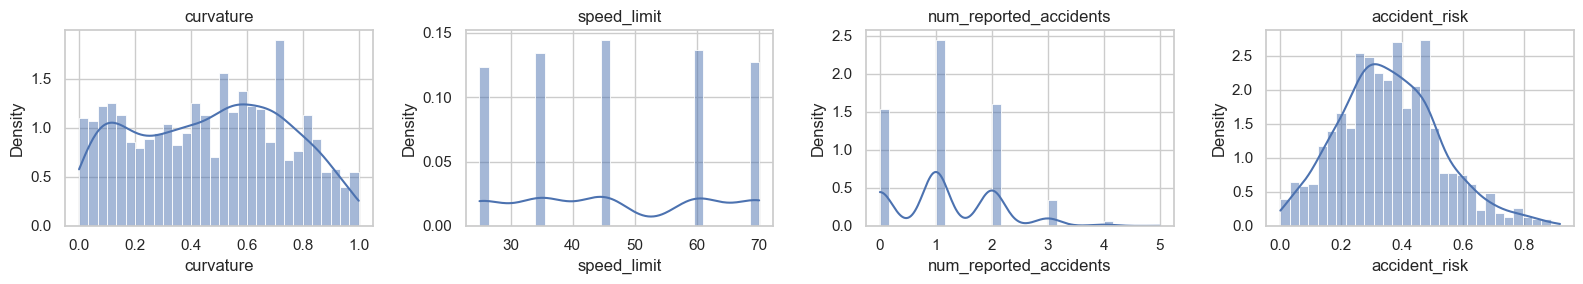

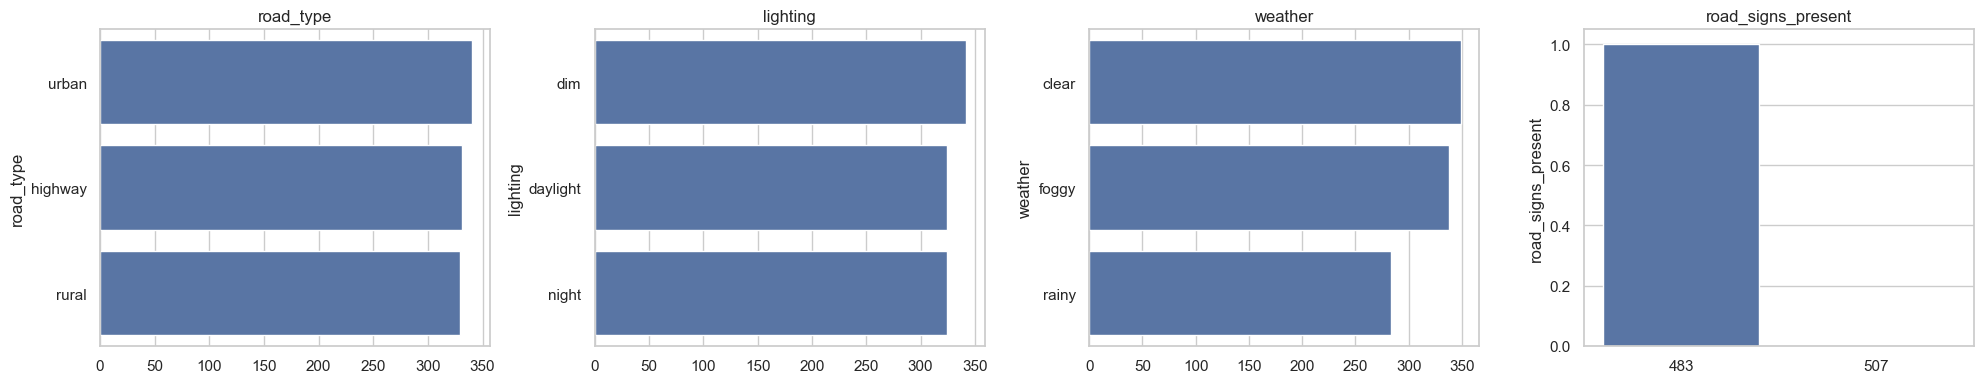

=== End summary for df_train_sample_missing (1k with injected NaNs) ===



In [44]:

# Compact exploratory helper for structure, dims and initial problem formulation
def explore_dataset(df, name="df"):
    print(f"=== Summary for {name} ===")
    print("Shape:", df.shape)
    print("Memory usage (MB):", df.memory_usage(deep=True).sum() / 1024**2)
    print("\nColumn types:")
    print(df.dtypes)
    print("\nFirst 3 rows:")
    display(df.head(3))
    
    # Missingness
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    miss_df = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})
    print("\nMissing values (top 10):")
    display(miss_df.sort_values("missing_count", ascending=False).head(10))
    
    # Numeric & categorical splits
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object", "bool", "category"]).columns.tolist()
    print(f"\nNumeric columns ({len(num_cols)}): {num_cols}")
    print(f"Categorical/Bool columns ({len(cat_cols)}): {cat_cols}")
    
    # Numeric summary
    if num_cols:
        print("\nNumeric summary (describe):")
        display(df[num_cols].describe().T)
    
    # Cardinality for categorical columns
    if cat_cols:
        print("\nCategorical columns cardinality and top values:")
        for c in cat_cols:
            top = df[c].value_counts(dropna=False).head(5)
            print(f" - {c}: nunique={df[c].nunique(dropna=True)} | top:\n{top}\n")
    
    # Potential targets and quick checks
    targets = []
    if "accident_risk" in df.columns:
        targets.append("accident_risk")
        ar = df["accident_risk"].dropna()
        print("accident_risk -> continuous? dtype:", df["accident_risk"].dtype,
              f" | range: {ar.min():.3f} - {ar.max():.3f} | mean: {ar.mean():.3f}")
    if "num_reported_accidents" in df.columns:
        targets.append("num_reported_accidents")
        vc = df["num_reported_accidents"].value_counts().sort_index()
        print("\nnum_reported_accidents -> count distribution (value: freq):")
        print(vc.head(20))
        print("Unique values:", df["num_reported_accidents"].nunique())
    
    # Problem formulation hint
    if targets:
        print("\nProblem formulation hints:")
        if "accident_risk" in targets:
            print(" - 'accident_risk' looks like a continuous target -> regression (or calibration) problem.")
        if "num_reported_accidents" in targets:
            print(" - 'num_reported_accidents' is an integer count -> classification (if small discrete set) or count/regression models (Poisson/neg. binomial) depending on distribution.")
        if len(targets) > 1:
            print(" - You can train separate models per target or multi-output models depending on the use-case.")
    else:
        print("\nNo obvious target column found in this dataframe.")
    
    # Quick visualizations: numeric histograms and categorical top-bars
    sns.set(style="whitegrid")
    
    if num_cols:
        n = len(num_cols)
        cols = min(4, n)
        rows = math.ceil(n / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
        axes = axes.flatten() if n > 1 else [axes]
        for i, c in enumerate(num_cols):
            sns.histplot(df[c].dropna(), ax=axes[i], kde=True, stat="density", bins=30)
            axes[i].set_title(c)
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()
    
    if cat_cols:
        # show top categories for up to 4 categorical columns
        show_cols = cat_cols[:4]
        fig, axes = plt.subplots(1, len(show_cols), figsize=(5*len(show_cols), 4))
        axes = axes if len(show_cols) > 1 else [axes]
        for ax, c in zip(axes, show_cols):
            top = df[c].value_counts().nlargest(10)
            sns.barplot(x=top.values, y=top.index, ax=ax)
            ax.set_title(c)
        plt.tight_layout()
        plt.show()
    
    print(f"=== End summary for {name} ===\n")

# Run exploration on relevant datasets / samples
explore_dataset(df_train_sample_missing, "df_train_sample_missing (1k with injected NaNs)")

In [45]:
from ydata_profiling import ProfileReport

prof = ProfileReport(df_train_sample_missing)

prof.to_file(output_file='output.html')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 630.72it/s]


## Lab 2: Data Preprocessing

In [46]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [47]:
target_cols = [c for c in ['accident_risk'] if c in df_train_sample_missing.columns]

numerical_cols = [c for c in df_train_sample_missing.select_dtypes(include=['number']).columns if c not in target_cols]
categorical_cols = df_train_sample_missing.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()


print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['curvature', 'speed_limit', 'num_reported_accidents']
Categorical columns: ['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road', 'holiday', 'school_season']


In [48]:
numeric_cols_to_impute = ['curvature']
categorical_cols_to_impute = ['lighting', 'weather', 'road_signs_present']
# --- 3. Impute Numeric Columns (using Median) ---
# Strategy = 'median' is robust to outliers
num_imputer = SimpleImputer(strategy='median')

# Fit and transform the numeric columns
df_train_sample_missing[numeric_cols_to_impute] = num_imputer.fit_transform(df_train_sample_missing[numeric_cols_to_impute])


# --- 4. Impute Categorical Columns (using Mode) ---
# Strategy = 'most_frequent' (the mode) is used for categorical/boolean data
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit and transform the categorical columns
df_train_sample_missing[categorical_cols_to_impute] = cat_imputer.fit_transform(df_train_sample_missing[categorical_cols_to_impute])

# --- 5. Verify the Results ---
print("\n--- Missing Values AFTER Imputation ---")
print(df_train_sample_missing.isnull().sum())


--- Missing Values AFTER Imputation ---
road_type                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64


In [49]:
# --- 3. Cap Outliers using IQR ---
for col in numerical_cols:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df_train_sample_missing[col].quantile(0.25)
    Q3 = df_train_sample_missing[col].quantile(0.75)

    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1
    
    # Calculate the upper and lower bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap the values in the column
    # np.clip(series, lower_limit, upper_limit)
    df_train_sample_missing[col] = np.clip(df_train_sample_missing[col], lower_bound, upper_bound)

print("\n--- Data Description AFTER Capping ---")
# Notice the min/max values are now "capped" at the bounds
print(df_train_sample_missing.describe())

print("\n--- Example: 'curvature' after capping ---")
# The outlier '50.0' has been replaced by the upper bound value
print(df_train_sample_missing['curvature'])


--- Data Description AFTER Capping ---
         curvature  speed_limit  num_reported_accidents  accident_risk
count  1000.000000  1000.000000             1000.000000    1000.000000
mean      0.470161    47.130000                1.160000       0.358620
std       0.268747    15.981818                0.912816       0.165749
min       0.000000    25.000000                0.000000       0.000000
25%       0.240000    35.000000                0.000000       0.250000
50%       0.490000    45.000000                1.000000       0.350000
75%       0.680000    60.000000                2.000000       0.470000
max       1.000000    70.000000                5.000000       0.920000

--- Example: 'curvature' after capping ---
0      0.06
1      0.99
2      0.63
3      0.07
4      0.58
       ... 
995    0.54
996    0.19
997    0.10
998    0.33
999    0.19
Name: curvature, Length: 1000, dtype: float64


In [50]:
df = df_train_sample_missing.copy()

In [51]:
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season']
categorical_cols = ['road_type', 'lighting', 'weather']

# --- 3. Step 1: Scale Numeric Columns ---
# We use StandardScaler (Z-score scaling)
# It's generally preferred over MinMaxScaler unless you need data in a [0, 1] range.
scaler = StandardScaler()

# Fit and transform the numeric columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\n\n--- DataFrame AFTER Scaling Numeric Cols ---")
# Note the mean is ~0 and std dev is ~1.0
print(df[numerical_cols].describe())


# --- 5. Step 3: Encode Categorical Columns ---
# We use pd.get_dummies() for One-Hot Encoding.
# This creates new columns for each category (e.g., 'weather_Clear', 'weather_Rain')
# and drops the original categorical columns.
df_processed = pd.get_dummies(df, 
                              columns=categorical_cols, 
                              drop_first=True)

# 'drop_first=True' is important to avoid multicollinearity,
# which can be a problem for some models (like linear regression).
# It drops one category (e.g., 'weather_Clear') as a baseline.


# --- 6. Show Final Result ---
print("\n\n--- FINAL Processed DataFrame ---")
print(df_processed.head())

print("\n--- FINAL Processed Data Types ---")
df_processed.info()



--- DataFrame AFTER Scaling Numeric Cols ---
          curvature   speed_limit  num_reported_accidents
count  1.000000e+03  1.000000e+03            1.000000e+03
mean  -1.527667e-16 -1.705303e-16            1.101341e-16
std    1.000500e+00  1.000500e+00            1.000500e+00
min   -1.750328e+00 -1.385391e+00           -1.271429e+00
25%   -8.568492e-01 -7.593673e-01           -1.271429e+00
50%    7.385834e-02 -1.333431e-01           -1.753695e-01
75%    7.811961e-01  8.056930e-01            9.206896e-01
max    1.972502e+00  1.431717e+00            4.208867e+00


--- FINAL Processed DataFrame ---
   curvature  speed_limit road_signs_present  public_road  holiday  \
0  -1.526959    -0.759367              False         True    False   
1   1.935273    -0.759367               True        False     True   
2   0.595055     1.431717              False         True     True   
3  -1.489730    -0.759367               True         True    False   
4   0.408913     0.805693              False 

In [52]:
df_processed.head()

,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy
0,-1.526959,-0.759367,False,True,False,True,-0.175369,0.13,False,True,False,False,False,True
1,1.935273,-0.759367,True,False,True,True,-1.271429,0.35,False,True,False,False,False,False
2,0.595055,1.431717,False,True,True,False,0.920690,0.30,True,False,True,False,False,False
3,-1.489730,-0.759367,True,True,False,False,-0.175369,0.21,False,False,True,False,False,True
4,0.408913,0.805693,False,False,True,False,-0.175369,0.56,True,False,False,False,True,False


In [53]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, pairwise_distances
# --- 2. Separate Target (y) from Features (X) ---
# This is the crucial step you asked for previously.
y = df_processed['accident_risk']
X = df_processed.drop('accident_risk', axis=1)

print("--- Calculating similarities on the FEATURES (X) ---")
print("X Head:")
print(X.head())
print("-" * 40)

# --- 3. Select the First 5 Rows of X ---
# We use .to_numpy() to pass arrays to scikit-learn
data_subset_np = X.iloc[:5].to_numpy()
row_labels = X.index[:5]


# --- 4. Calculate Cosine Similarity ---
# Applied to the entire feature vector X
cos_sim_matrix = cosine_similarity(data_subset_np)
print("\n--- Cosine Similarity (First 5x5) ---")
print(pd.DataFrame(cos_sim_matrix, 
                   index=row_labels, 
                   columns=row_labels))


# --- 5. Calculate Euclidean Distance ---
# Applied to the entire feature vector X
euc_dist_matrix = euclidean_distances(data_subset_np)
print("\n--- Euclidean Distance (First 5x5) ---")
print(pd.DataFrame(euc_dist_matrix, 
                   index=row_labels, 
                   columns=row_labels))


# --- 6. Calculate Jaccard Similarity (on Binary Features of X) ---
# Identify binary columns *within X*
binary_cols_in_X = [col for col in X.columns if col not in numerical_cols]

# Get the binary data subset *as a NumPy array*
data_subset_binary_np = X.iloc[:5][binary_cols_in_X].to_numpy()

print(f"\nCalculating Jaccard Similarity on {len(binary_cols_in_X)} binary columns from X.")

# Calculate Jaccard *distance* (1 - similarity)
jaccard_dist_matrix = pairwise_distances(data_subset_binary_np, metric='jaccard')

# Jaccard Similarity = 1 - Jaccard Distance
jaccard_sim_matrix = 1 - jaccard_dist_matrix

print("\n--- Jaccard Similarity (First 5x5) - (Binary Features Only) ---")
print(pd.DataFrame(jaccard_sim_matrix, 
                   index=row_labels, 
                   columns=row_labels))

--- Calculating similarities on the FEATURES (X) ---
X Head:
   curvature  speed_limit road_signs_present  public_road  holiday  \
0  -1.526959    -0.759367              False         True    False   
1   1.935273    -0.759367               True        False     True   
2   0.595055     1.431717              False         True     True   
3  -1.489730    -0.759367               True         True    False   
4   0.408913     0.805693              False        False     True   

   school_season  num_reported_accidents  road_type_rural  road_type_urban  \
0           True               -0.175369            False             True   
1           True               -1.271429            False             True   
2          False                0.920690             True            False   
3          False               -0.175369            False            False   
4          False               -0.175369             True            False   

   lighting_dim  lighting_night  weather_foggy  w

c:\Users\ASUS\anaconda3\envs\py31013\lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


# **Exploratory Data Analysis**


--- EDA Part 1: Numeric Distributions (Histograms) ---


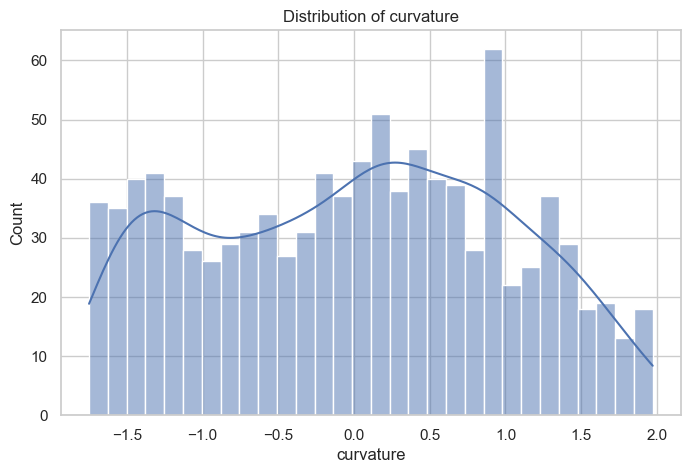

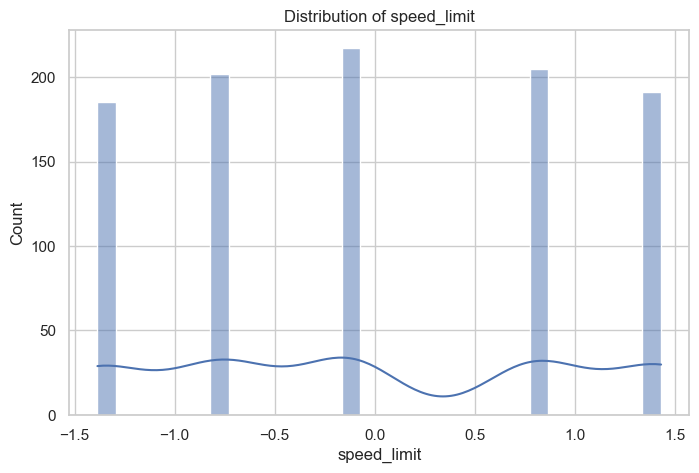

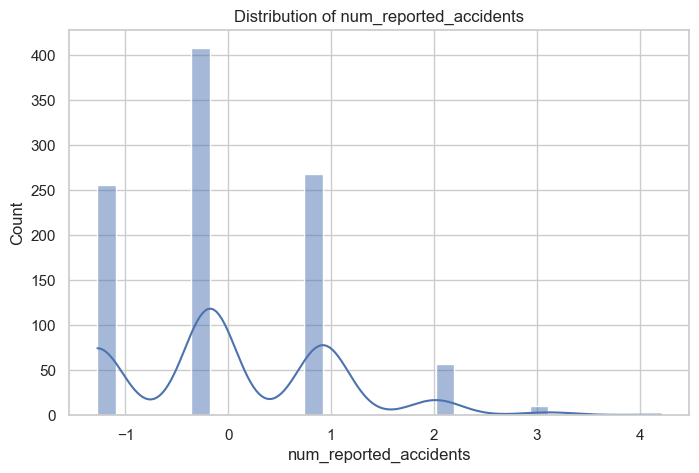

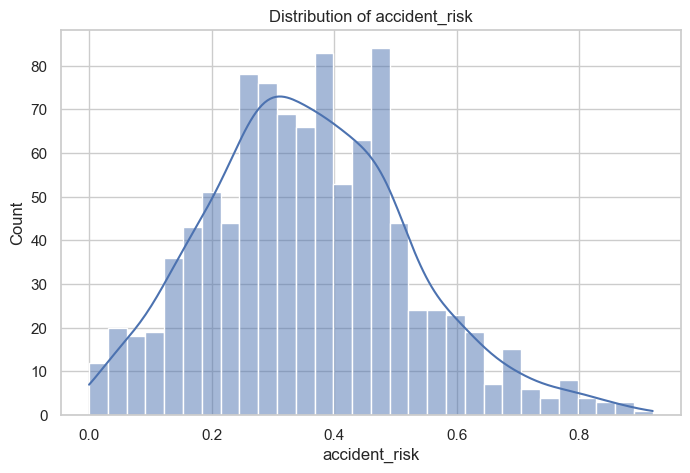


--- EDA Part 2: Numeric Outlier Analysis (Boxplots) ---


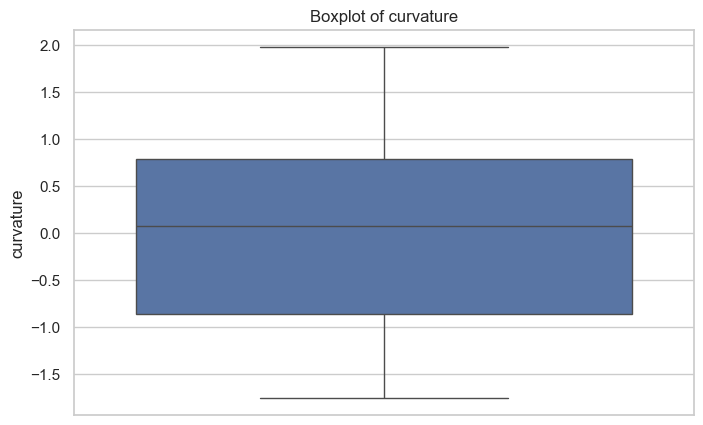

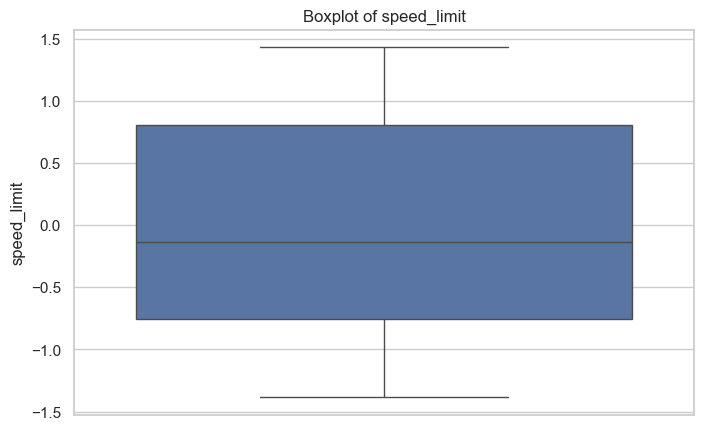

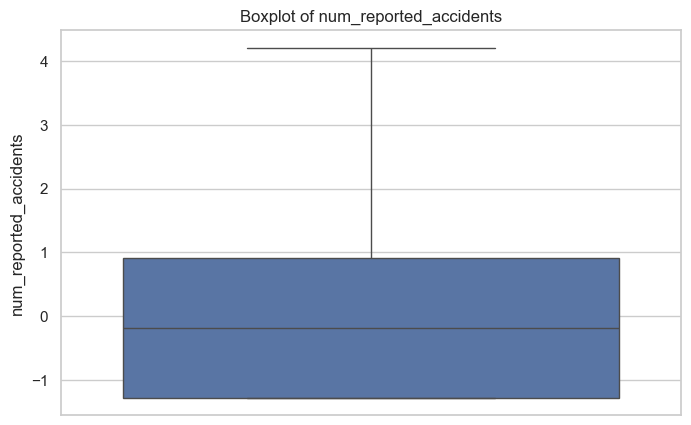

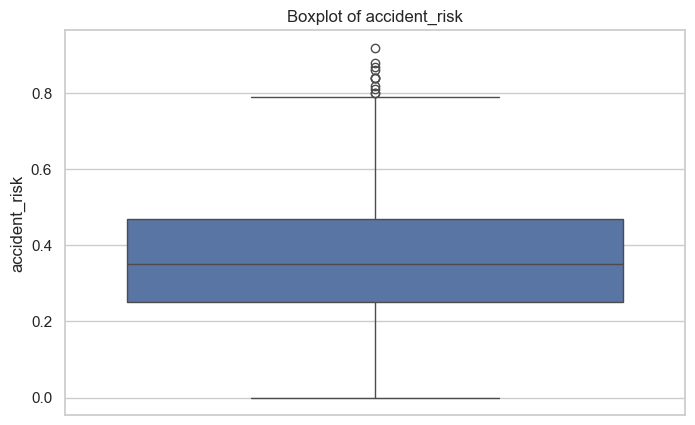


--- EDA Part 3: Pairwise Relationships (Pairplot) ---


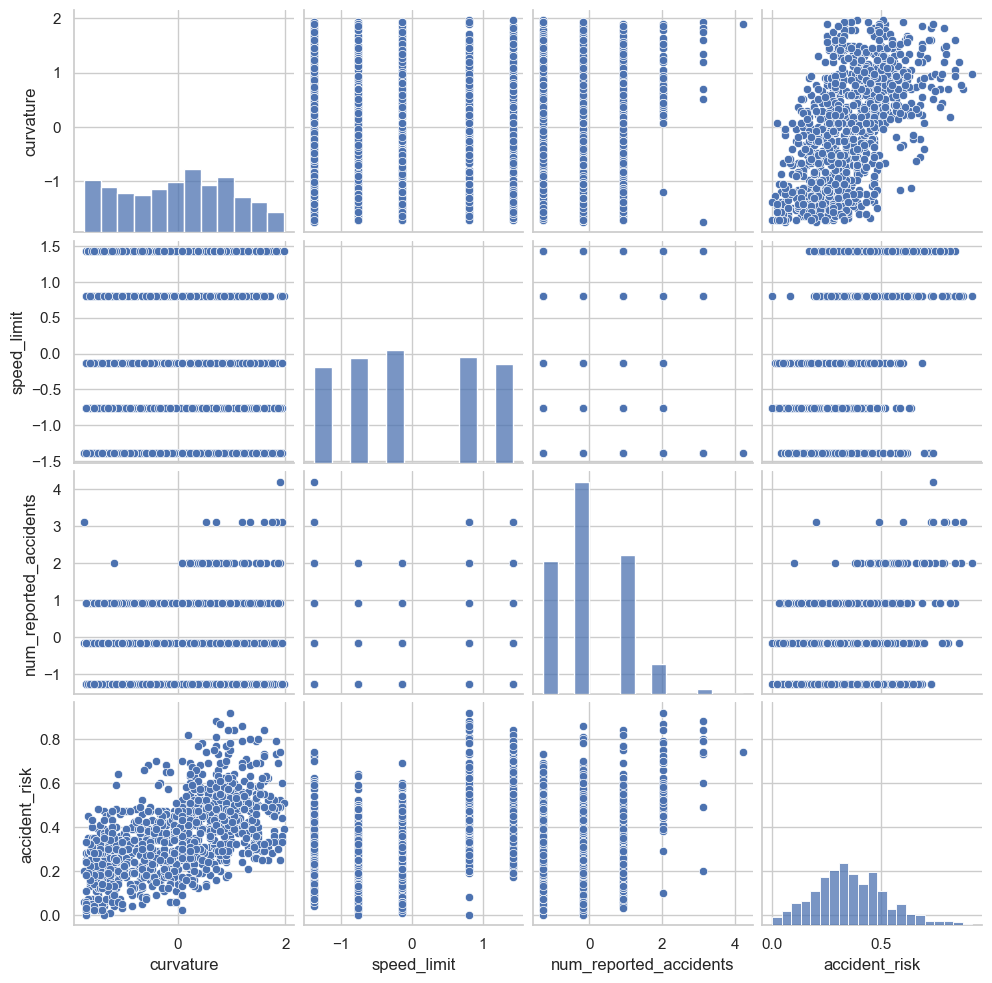


--- EDA Part 4: Pairwise Correlation Matrix ---
                        curvature  speed_limit  num_reported_accidents  \
curvature                1.000000    -0.017264                0.124104   
speed_limit             -0.017264     1.000000               -0.011377   
num_reported_accidents   0.124104    -0.011377                1.000000   
accident_risk            0.533362     0.412833                0.215689   

                        accident_risk  
curvature                    0.533362  
speed_limit                  0.412833  
num_reported_accidents       0.215689  
accident_risk                1.000000  


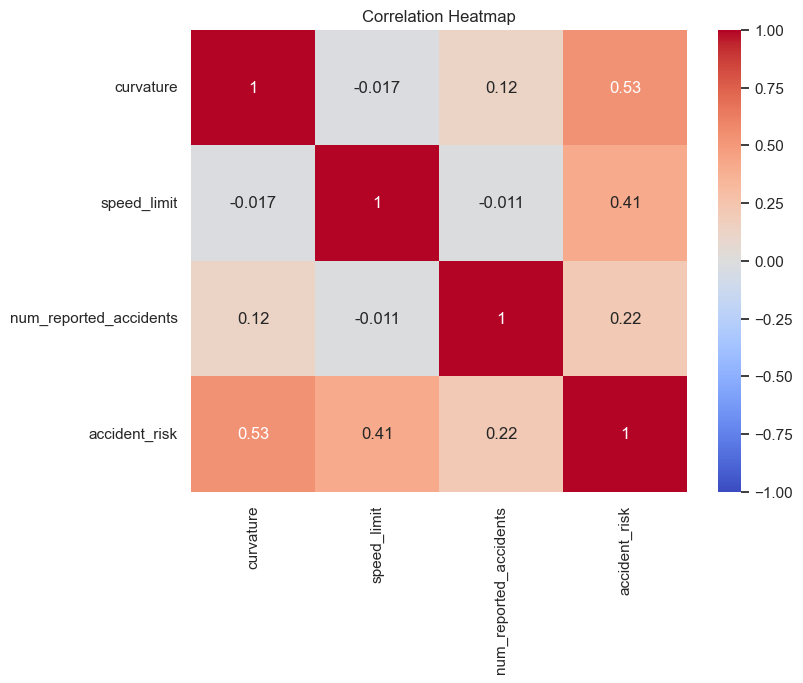


--- EDA Part 5: Categorical Variable Counts ---


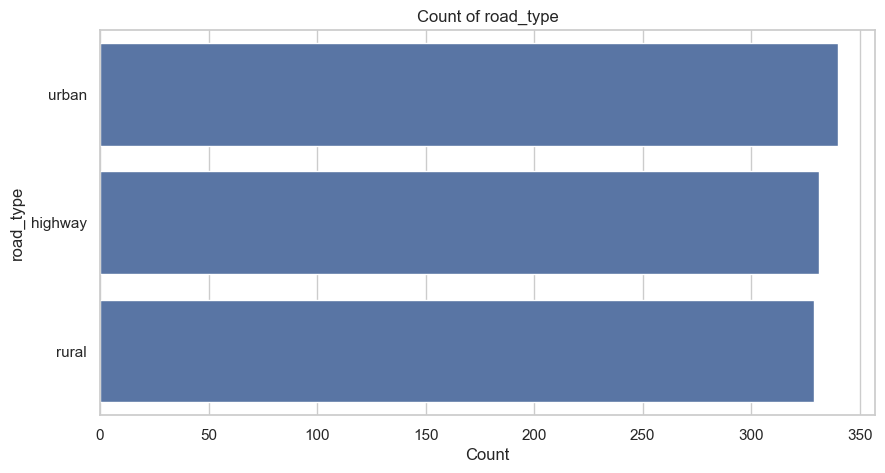

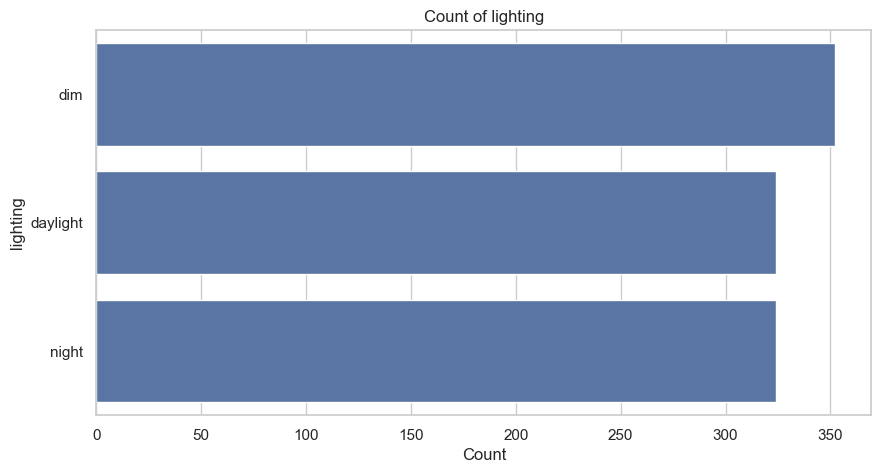

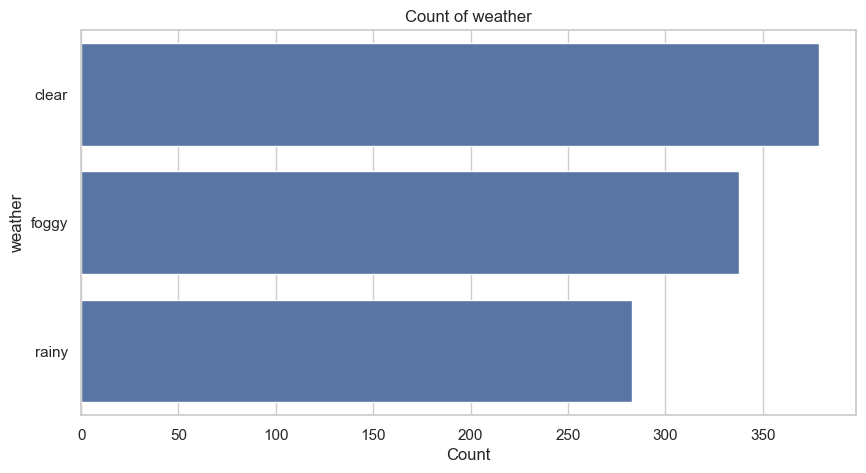

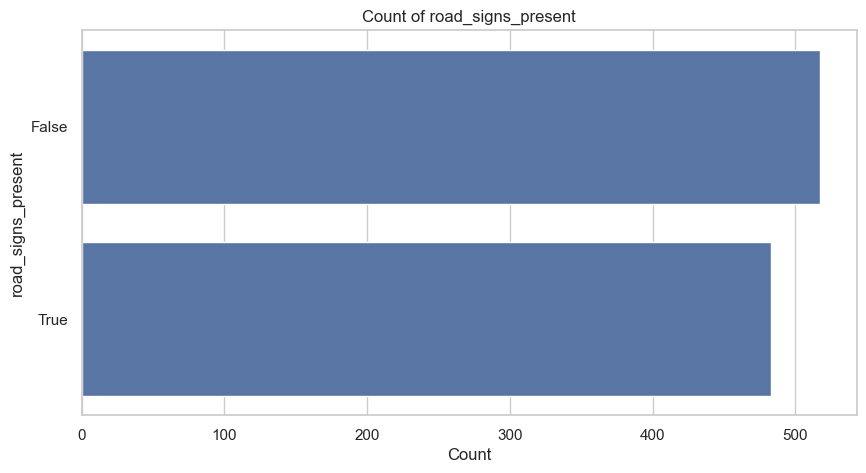

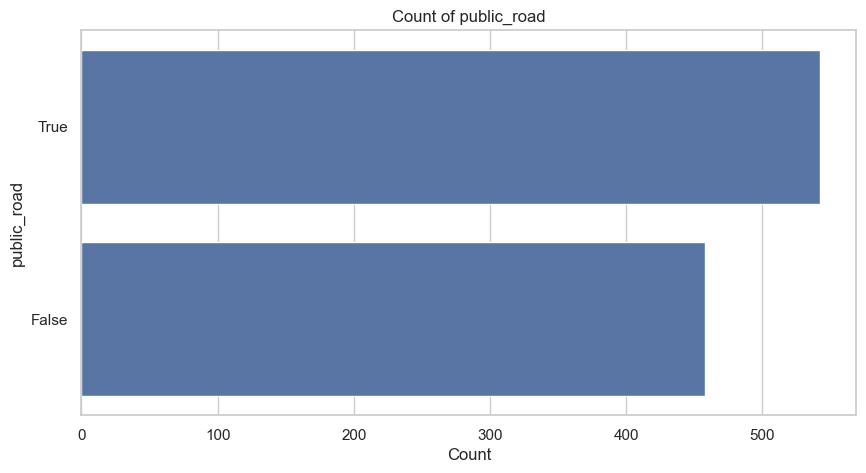

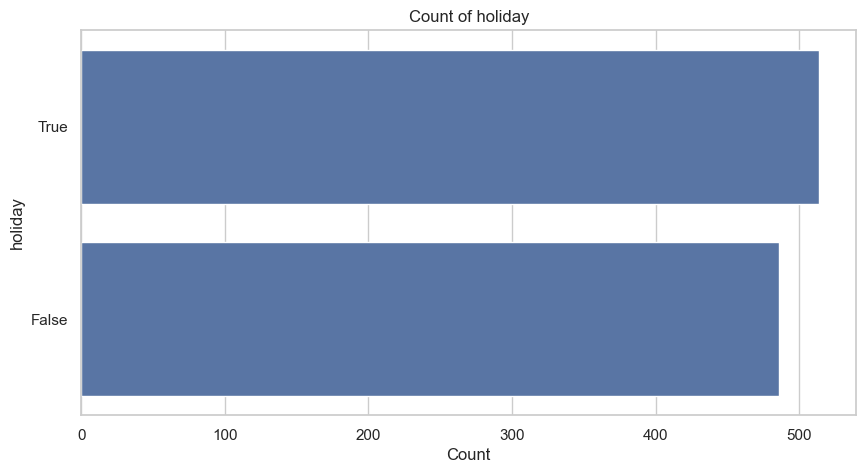

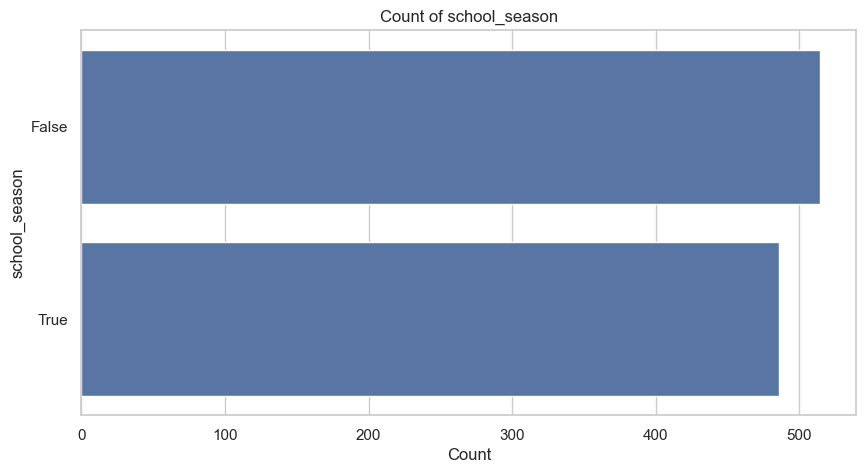

In [54]:

num_cols = ['curvature', 'speed_limit', 'num_reported_accidents', 'accident_risk']
Categorical=['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road', 'holiday', 'school_season']
# --- 2. Distribution of Numeric Columns (Histograms) ---
print("\n--- EDA Part 1: Numeric Distributions (Histograms) ---")
for col in num_cols:
    plt.figure(figsize=(8, 5))
    # 'kde=True' adds the smooth density line
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# --- 3. Outlier Analysis (Boxplots) ---
print("\n--- EDA Part 2: Numeric Outlier Analysis (Boxplots) ---")
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# --- 4. Pairwise Relationships (Pairplot) ---
# A pairplot shows scatter plots for every pair of numeric variables
print("\n--- EDA Part 3: Pairwise Relationships (Pairplot) ---")
# We use all 4 numeric cols, including the target
sns.pairplot(df[num_cols])
plt.show()

# --- 5. Correlation Matrix ---
print("\n--- EDA Part 4: Pairwise Correlation Matrix ---")
corr_matrix = df[num_cols].corr(method='pearson')
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


# --- 6. (Bonus) Analysis of Categorical Columns ---
# It's also crucial to check the counts of your categorical variables
print("\n--- EDA Part 5: Categorical Variable Counts ---")
for col in Categorical:
    plt.figure(figsize=(10, 5))
    # Use .astype(str) to treat NaN as a separate category 'nan'
    sns.countplot(y=df[col].astype(str), order=df[col].astype(str).value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

In [55]:
# --- 2. Discretize the Target Column ---

# Define the labels for the new categories
labels = ['Low', 'Medium', 'High']

# Use pd.qcut() to create 3 bins (q=3) based on quantiles
# duplicates='drop' handles cases where bin edges are identical
y = pd.qcut(y, q=3, labels=labels, duplicates='drop')

y.name = 'accident_risk'

# --- 3. Verify the Results ---
print("\n" + "="*40)
print("\n--- Discretized Target (y) ---")
print(y.head())

print("\n--- Value Counts for Each New Category ---")
# The counts should be as equal as possible
print(y.value_counts())



--- Discretized Target (y) ---
0       Low
1    Medium
2    Medium
3       Low
4      High
Name: accident_risk, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

--- Value Counts for Each New Category ---
accident_risk
Low       345
High      332
Medium    323
Name: count, dtype: int64


In [56]:
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("\nTarget (y) value counts:")
print(y.value_counts())

Features (X) shape: (1000, 13)
Target (y) shape: (1000,)

Target (y) value counts:
accident_risk
Low       345
High      332
Medium    323
Name: count, dtype: int64


# **Classification with Decision Trees**

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)


--- Decision Tree (Entropy) ---
Test Accuracy (Entropy): 0.725

Classification Report (Entropy):
              precision    recall  f1-score   support

        High       0.83      0.76      0.80        51
         Low       0.80      0.78      0.79        85
      Medium       0.56      0.62      0.59        64

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.73       200
weighted avg       0.73      0.72      0.73       200


Feature Importance (Entropy):
curvature                 0.341258
lighting_night            0.182267
speed_limit               0.154469
num_reported_accidents    0.056927
weather_foggy             0.054284
weather_rainy             0.040579
road_signs_present        0.034358
public_road               0.027726
holiday                   0.026776
school_season             0.023247
road_type_urban           0.020306
lighting_dim              0.019388
road_type_rural           0.018416
dtype: float64


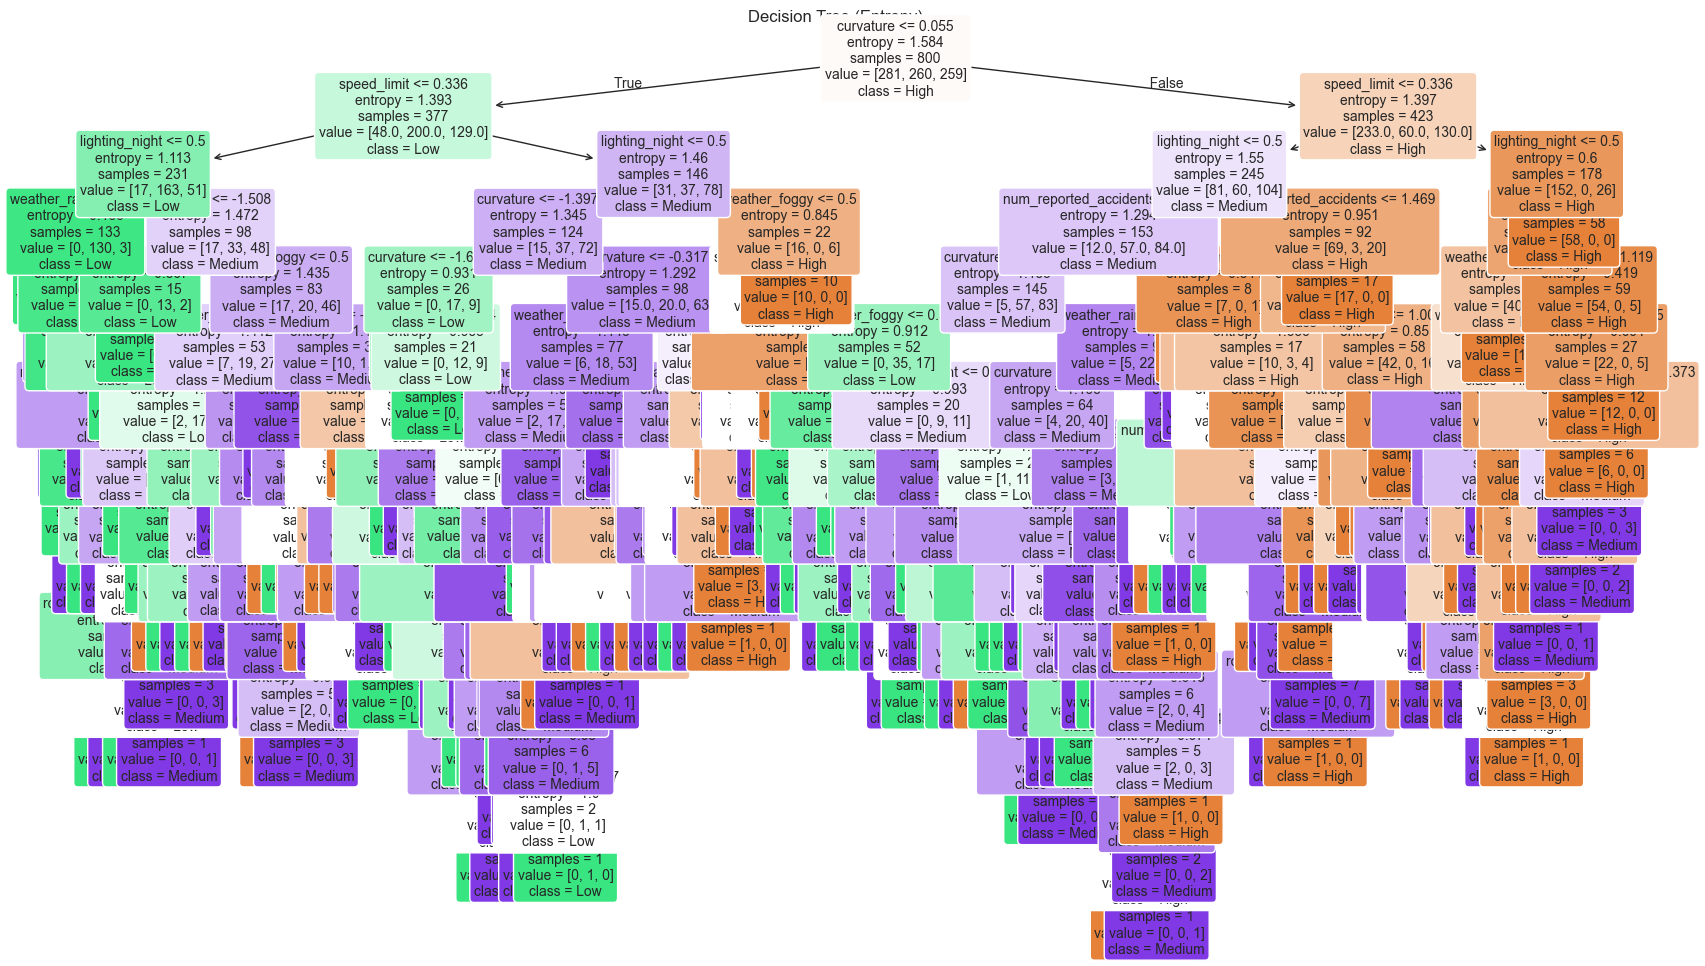


--- Decision Tree (Gini) ---
Test Accuracy (Gini): 0.735

Classification Report (Gini):
              precision    recall  f1-score   support

        High       0.80      0.84      0.82        51
         Low       0.78      0.81      0.79        85
      Medium       0.61      0.55      0.58        64

    accuracy                           0.73       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.73      0.73      0.73       200


Feature Importance (Gini):
curvature                 0.324698
lighting_night            0.169233
speed_limit               0.159945
num_reported_accidents    0.058107
weather_foggy             0.051591
weather_rainy             0.046781
holiday                   0.036253
school_season             0.034088
road_type_urban           0.033911
road_signs_present        0.029536
public_road               0.025533
road_type_rural           0.016309
lighting_dim              0.014016
dtype: float64


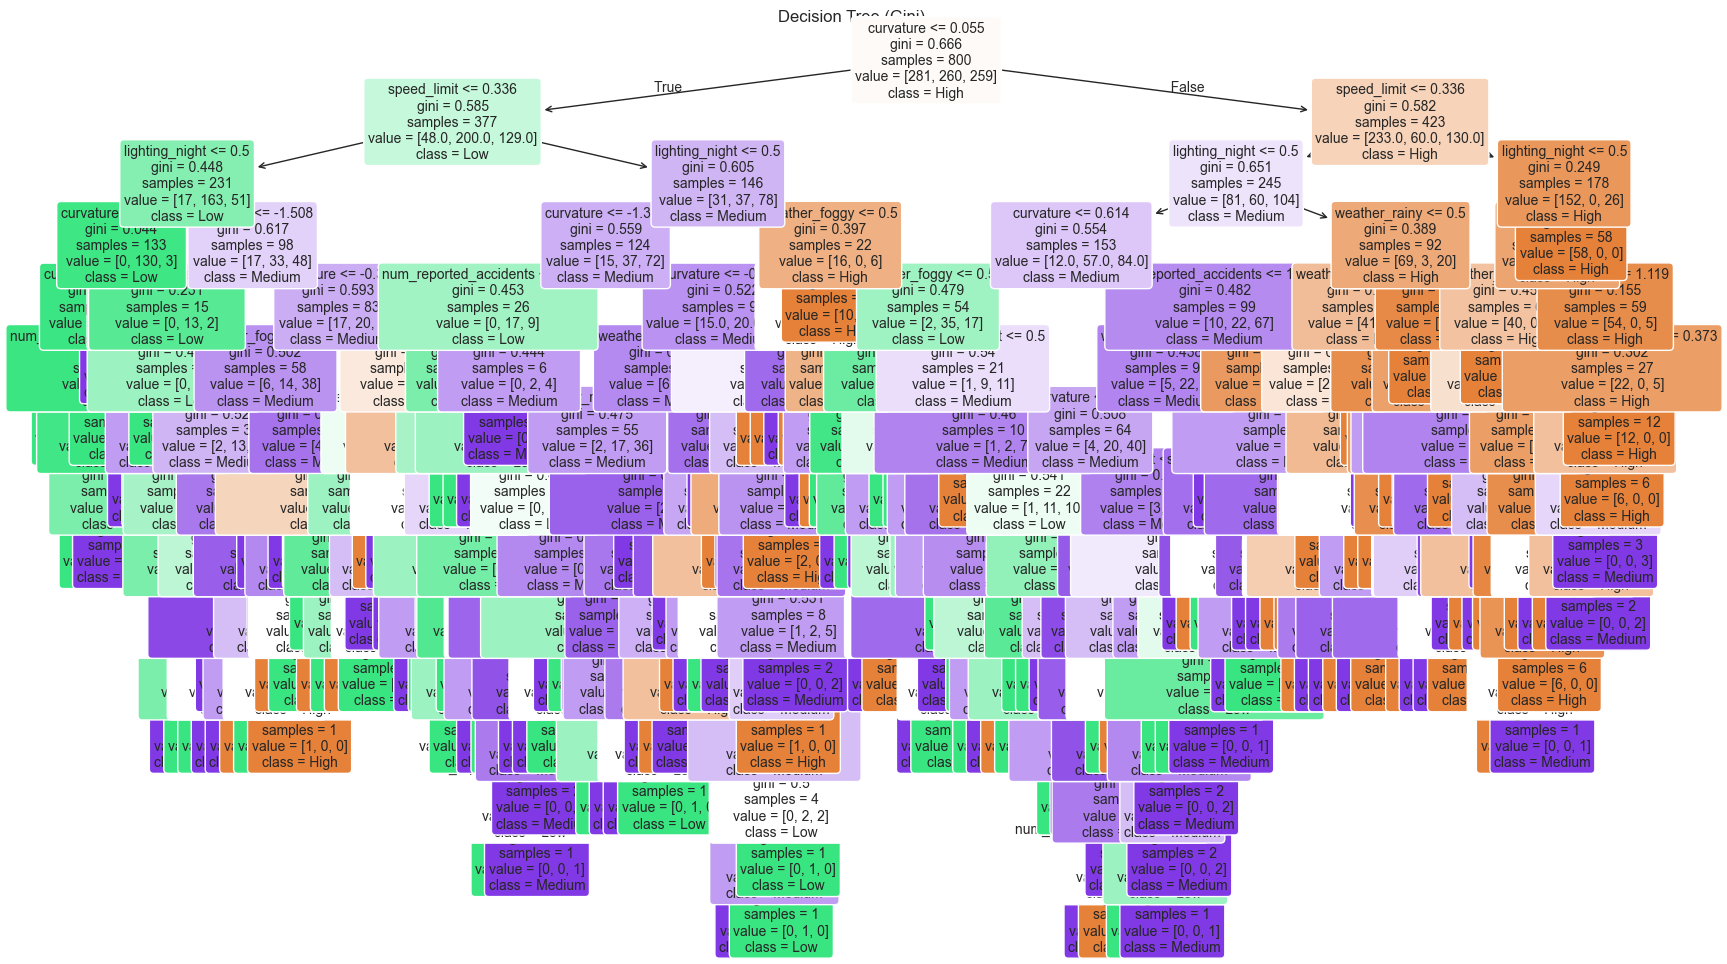

In [59]:
# --- 6. Classification with Decision Tree (Entropy) ---
print("\n" + "="*40)
print("--- Decision Tree (Entropy) ---")
print("="*40)

# Initialize and train the model
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

# Make predictions
y_pred_entropy = dt_entropy.predict(X_test)

# Evaluate the model
print("Test Accuracy (Entropy):", accuracy_score(y_test, y_pred_entropy))
print("\nClassification Report (Entropy):")
print(classification_report(y_test, y_pred_entropy))

# Feature importance
importances_entropy = pd.Series(dt_entropy.feature_importances_, index=X.columns)
print("\nFeature Importance (Entropy):")
print(importances_entropy.sort_values(ascending=False))

# Plot the tree
plt.figure(figsize=(20, 12)) # Increased size for better readability
plot_tree(dt_entropy, 
          feature_names=X.columns, 
          class_names=dt_entropy.classes_, # Use the learned class names
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Decision Tree (Entropy)')
plt.show()

# --- 7. Classification with Decision Tree (Gini) ---
print("\n" + "="*40)
print("--- Decision Tree (Gini) ---")
print("="*40)

# Initialize and train the model
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

# Make predictions
y_pred_gini = dt_gini.predict(X_test)

# Evaluate the model
print("Test Accuracy (Gini):", accuracy_score(y_test, y_pred_gini))
print("\nClassification Report (Gini):")
print(classification_report(y_test, y_pred_gini))

# Feature importance
importances_gini = pd.Series(dt_gini.feature_importances_, index=X.columns)
print("\nFeature Importance (Gini):")
print(importances_gini.sort_values(ascending=False))

# Plot the tree
plt.figure(figsize=(20, 12)) # Increased size for better readability
plot_tree(dt_gini, 
          feature_names=X.columns, 
          class_names=dt_gini.classes_, # Use the learned class names
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Decision Tree (Gini)')
plt.show()

# **Clustering with k-Means and Hierarchical**

In [60]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from mpl_toolkits.mplot3d import Axes3D


--- Lab 6: Clustering ---
Clustering on 1000 samples and 3 numeric features.


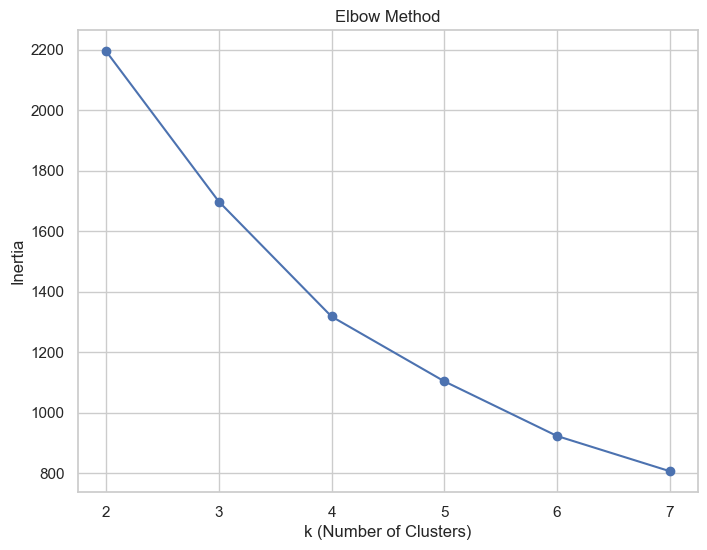

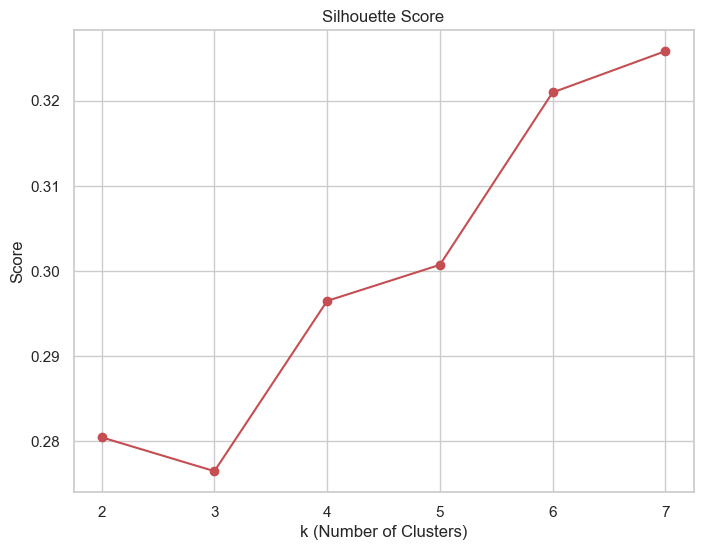


Silhouette Score for k=3: 0.2764801300575582


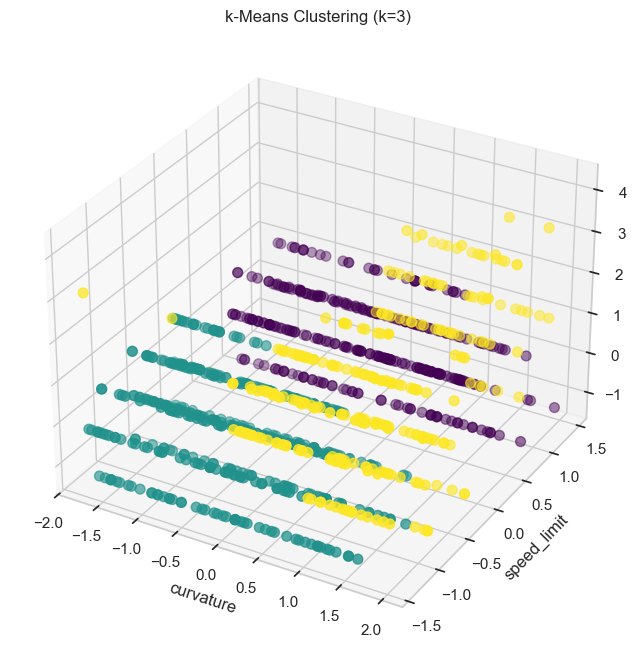

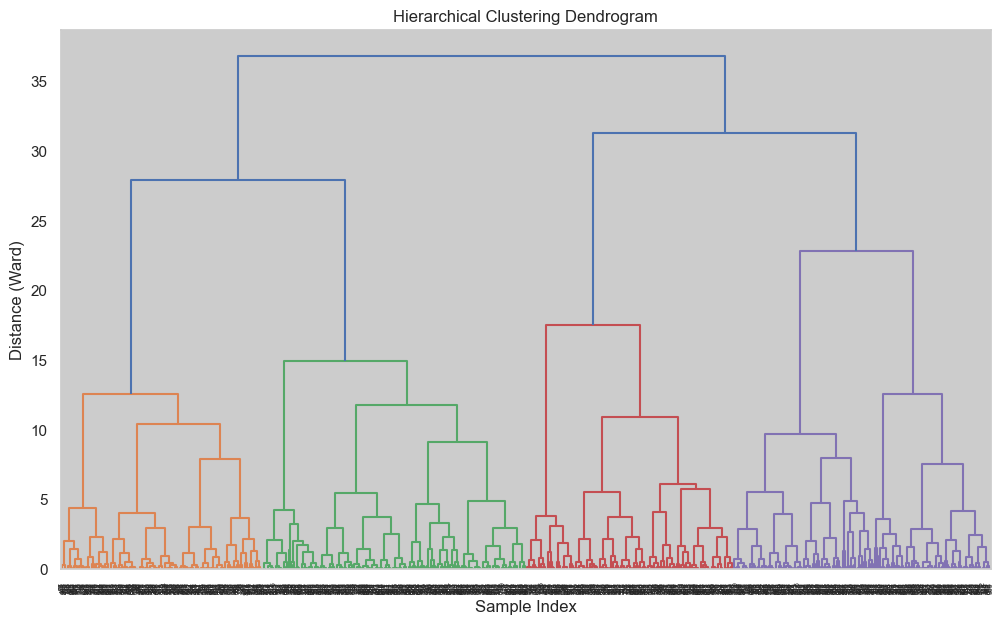

In [61]:
# --- 2. Prepare Data for Clustering ---
print("\n--- Lab 6: Clustering ---")

# Select only the scaled numeric columns for clustering, as in your example
X_scaled = X[numerical_cols].to_numpy()
print(f"Clustering on {X_scaled.shape[0]} samples and {X_scaled.shape[1]} numeric features.")


# --- 3. Find Optimal k (Elbow & Silhouette) ---
inertia = []
silhouette_scores = []
K = range(2, 8) # k range from 2 to 7

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bo-')
plt.title('Elbow Method')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Inertia')
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(K, silhouette_scores, 'ro-')
plt.title('Silhouette Score')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Score')
plt.show()


# --- 4. Run Final k-Means Model ---
# Based on the plots, we can select an optimal k. We'll use 3 as in your example.
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

print(f"\nSilhouette Score for k={optimal_k}:", silhouette_score(X_scaled, kmeans.labels_))

# --- 5. 3D Scatter Plot for Clustering ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], 
           c=kmeans.labels_, cmap='viridis', s=50)

# Set labels from our numerical_cols list
ax.set_xlabel(numerical_cols[0])
ax.set_ylabel(numerical_cols[1])
ax.set_zlabel(numerical_cols[2])
plt.title(f'k-Means Clustering (k={optimal_k})')
plt.show()


# --- 6. Hierarchical Clustering ---
# Calculate the linkage matrix
linkage_matrix = linkage(X_scaled, method='ward', metric='euclidean')

# Plot the dendrogram
plt.figure(figsize=(12, 7))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.show()

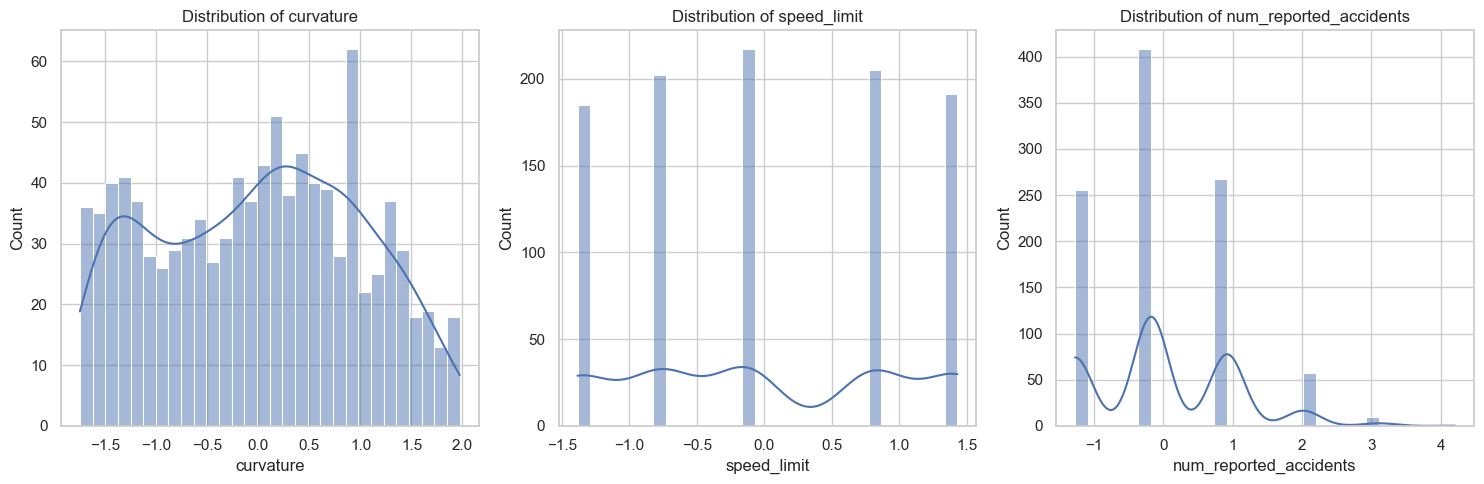

In [70]:
# Plot numerical columns in a single row
n = len(numerical_cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
# Ensure axes is iterable
axes = np.atleast_1d(axes)

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

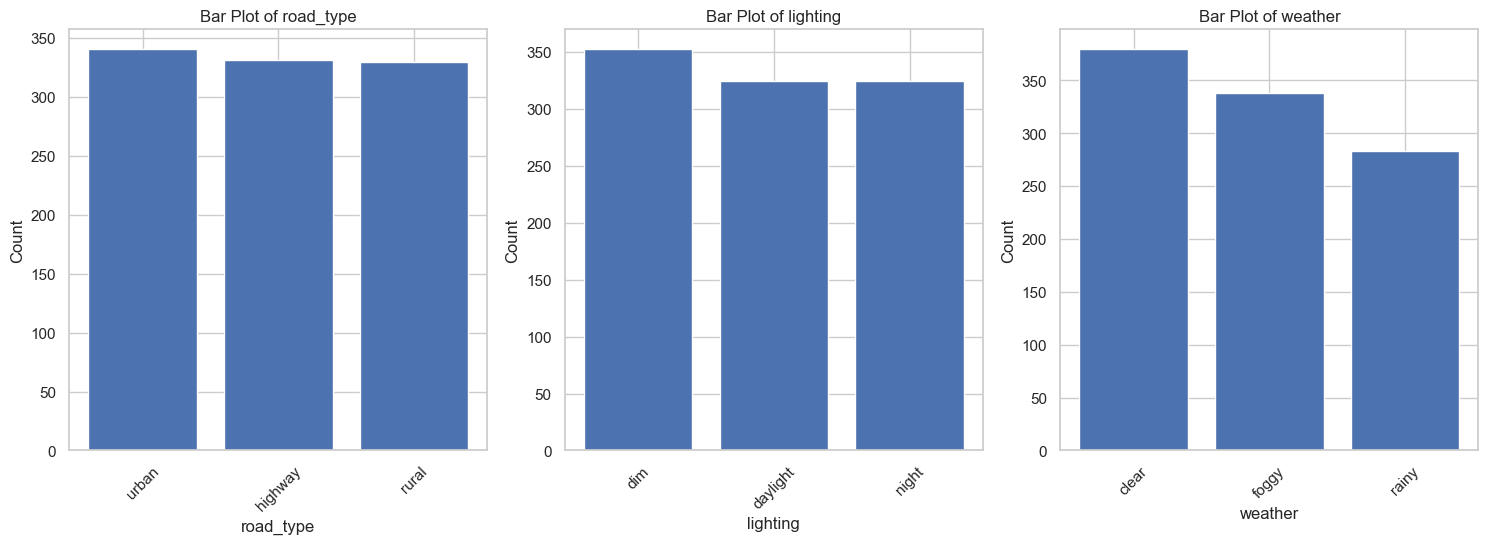

In [71]:
# Create bar plots for categorical columns
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        value_counts = df[col].value_counts()
        axes[i].bar(value_counts.index, value_counts.values)
        axes[i].set_title(f'Bar Plot of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()